In [20]:
# ============================================================
# Development settings
# ============================================================
%load_ext autoreload
%autoreload 2

# ============================================================
# Standard library
# ============================================================
import sys
from pathlib import Path
import matplotlib.colors as mcolors
import colorcet as cc
# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# ============================================================
# Scientific / geospatial libraries
# ============================================================
import geopandas as gpd
from pathlib import Path
from shapely.geometry import Point, LineString, MultiLineString
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import colorcet as cc
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors


# ============================================================
# Project modules
# ============================================================

from src.plotting_function import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"

print("Project root:", PROJECT_ROOT)
print("Data:", DATA_DIR)
print("Figures:", FIGURE_DIR)

Project root: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification
Data: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data
Figures: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\figures


## Spatial Aggregation for Global Hazard Visualization

The mapped hazard dataset retains information at the resolution of the Global Coastal Transect System (GCTS). While this resolution is appropriate for the multi-hazard analysis, directly displaying millions of closely spaced transects on a global map would result in substantial visual overlap and unnecessary computational demand. The data are therefore spatially aggregated to generalized coastline segments for visualization purposes only.

First, the mapped coastal transects are represented by their midpoint locations to provide point observations of the associated hazard attributes. A generalized global coastline derived from OpenStreetMap is then divided into approximately equal-length segments. A buffer is constructed around each segment and used to identify the coastal transects located in its vicinity.

The hazard values associated with the matched transects are aggregated using the **median** and assigned to the corresponding generalized coastline segment. The median is used to represent the typical local hazard condition while reducing the influence of individual extreme observations.

This aggregation does not modify the original transect-level hazard dataset used in the subsequent multi-hazard analysis. It is applied only to produce a computationally efficient and visually interpretable representation of the global spatial distribution.

**Processing sequence:**
1. Read the integrated transect-level hazard dataset.
2. Convert each coastal transect to a representative point.
3. Read the generalized global coastline.
4. Divide the coastline into fixed-length segments.
5. Construct a buffer around each segment.
6. Spatially associate transect points with the buffered coastline segments.
7. Aggregate hazard values within each segment using the median.


In [ ]:
# read mapped hazard andc onvert to point data
gdf = gpd.read_parquet(DATA_DIR / 'mapped_hazard.parquet')
gdf_centroid = gdf.assign(
    geometry=gpd.GeoSeries.from_xy(
        gdf.geometry.to_crs(epsg=3857).centroid.x, 
        gdf.geometry.to_crs(epsg=3857).centroid.y,
        crs="EPSG:3857").to_crs(epsg=4326)
    )

In [23]:
cl_files = DATA_DIR / 'coastlines_osm_generalized_v2023/coast_3857_gen9.shp'
target = gpd.read_file(cl_files)
source = gdf_centroid.to_crs(target.crs)


In [ ]:
segment_length = 250000               # segment length in meters (e.g., 1000, 5000, 10000)
buffer_size = 500                     # buffer in meters for finding points around segment

In [25]:
# -----------------------------
# 1. Split each line into equal-length segments
# -----------------------------
def split_line(line, segment_length):
    """Split a LineString into equal-length segments."""
    if line.length <= segment_length:
        return [line]
    num_segments = int(np.ceil(line.length / segment_length))
    return [
        LineString([line.interpolate(i * segment_length),
                    line.interpolate(min((i + 1) * segment_length, line.length))])
        for i in range(num_segments)
    ]

# -----------------------------
# 2. Split all target lines into segments
# -----------------------------
segment_geoms = []
for line in target.geometry:
    segment_geoms.extend(split_line(line, segment_length))

segments_gdf = gpd.GeoDataFrame(geometry=segment_geoms, crs=target.crs)

# -----------------------------
# 3. Buffer all segments at once (vectorized)
# -----------------------------
segments_gdf["buffer_geom"] = segments_gdf.geometry.buffer(buffer_size)
buffer_gdf = segments_gdf[["buffer_geom"]].rename(columns={"buffer_geom": "geometry"})
# buffer_gdf.to_file(f"gis/buffer_{buffer_size}_for_{segment_length}.gpkg", driver="GPKG")
# -----------------------------
# 4. Align CRS between points and buffers
# -----------------------------
points_gdf = source.to_crs(buffer_gdf.crs)

# -----------------------------
# 5. Spatial join (vectorized, uses internal R-tree)
# -----------------------------
joined = gpd.sjoin(points_gdf, buffer_gdf, how="inner", predicate="within")

In [26]:
def aggregate_data(segments_gdf,joined, key):
    
    agg_df = segments_gdf.copy()
    # -----------------------------
    # Aggregate point attributes for each segment
    # -----------------------------
    agg = joined.groupby("index_right")[key].median()  # mean, sum, min, max, etc.

    # -----------------------------
    # Map aggregated results back to segments
    # -----------------------------
    agg_df[key] = agg_df.index.map(agg)

    # -----------------------------
    # Cleanup
    # -----------------------------
    agg_df = agg_df.drop(columns=["buffer_geom"])
    agg_df[key] = agg_df[key].fillna(np.nan)

    return agg_df

## Global Distribution of Coastal Flood Hazard

The coastal flood dataset is visualized using the mean flood depth previously sampled along each GCTS transect. For global visualization, the transect-level values are aggregated to the generalized coastline segments using the median value of the transects associated with each segment.

Flood depth is divided into discrete intervals to distinguish areas characterized by relatively shallow inundation from locations exposed to greater flood depths. The resulting map provides an overview of the spatial distribution and concentration of coastal flood hazard at the global scale.

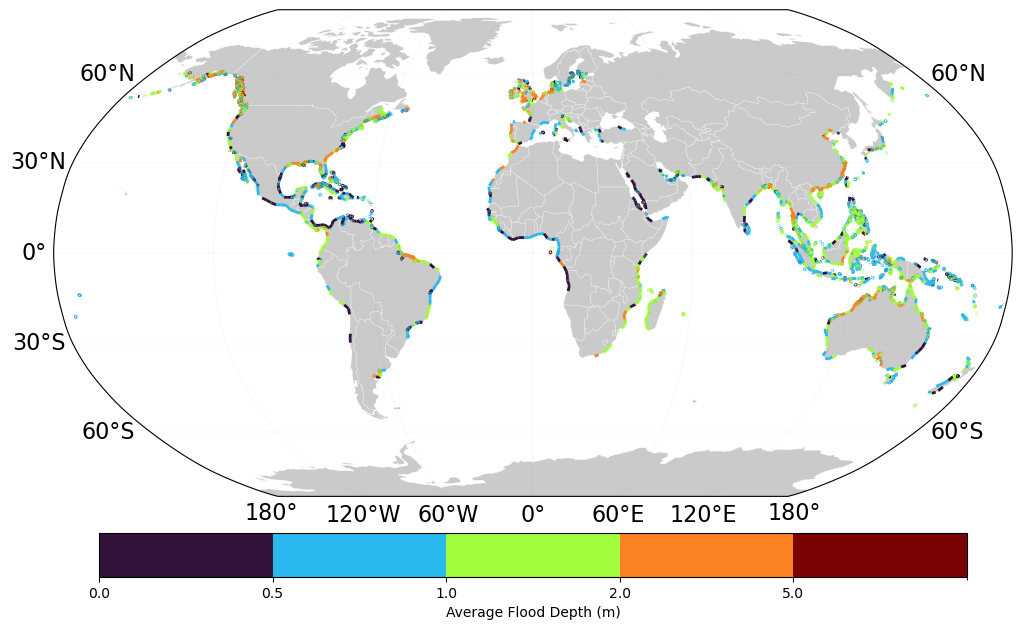

In [27]:
bins = [0, 0.5, 1, 2, 5, 6]

label = "Average Flood Depth (m)"
key = 'flood_mean'
flood_df = aggregate_data(segments_gdf,joined, key)
fig1 = visualize_hazard(flood_df,key,bins = bins,label=label)




### Flood Hazard Distribution and Extreme Threshold

The global statistical distribution of transect-level flood depth is evaluated using an empirical cumulative distribution function (ECDF). The ECDF is expressed here as an **exceedance probability**, representing the fraction of mapped coastal transects with flood depth greater than a given value.

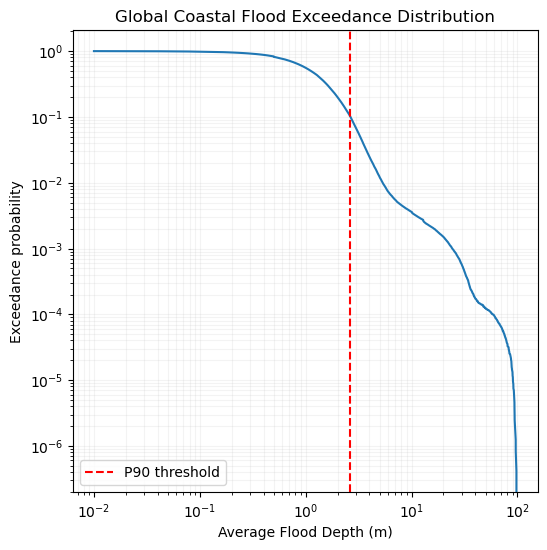

In [28]:
x,y = ecdf(gdf_centroid,key,label=label)


fig, ax = plt.subplots(figsize=(6,6))

plt.plot(x, 1-y)
    
for p in [90]:
    val = np.percentile(x, p)
    plt.axvline(val, linestyle='--',color='red',label='P90 threshold')


plt.xlabel(label)
plt.xscale('log')
plt.yscale("log")
plt.ylabel("Exceedance probability")
plt.title("Global Coastal Flood Exceedance Distribution")
plt.legend(loc='lower left')
plt.grid(True, which="both", alpha=0.15)
plt.show()


## Global Distribution of Shoreline Change

Shoreline-change rates are visualized to characterize the global distribution of coastal erosion and accretion. Negative shoreline-change rates represent shoreline retreat (erosion), whereas positive values represent shoreline advance (accretion).

Transect-level shoreline-change rates are aggregated to the generalized coastline segments using the median value of nearby transects. The map emphasizes the spatial distribution and relative magnitude of shoreline retreat while retaining accreting segments as a separate part of the shoreline-change range.

A discrete sequential color scale is used to distinguish increasing magnitudes of shoreline retreat.


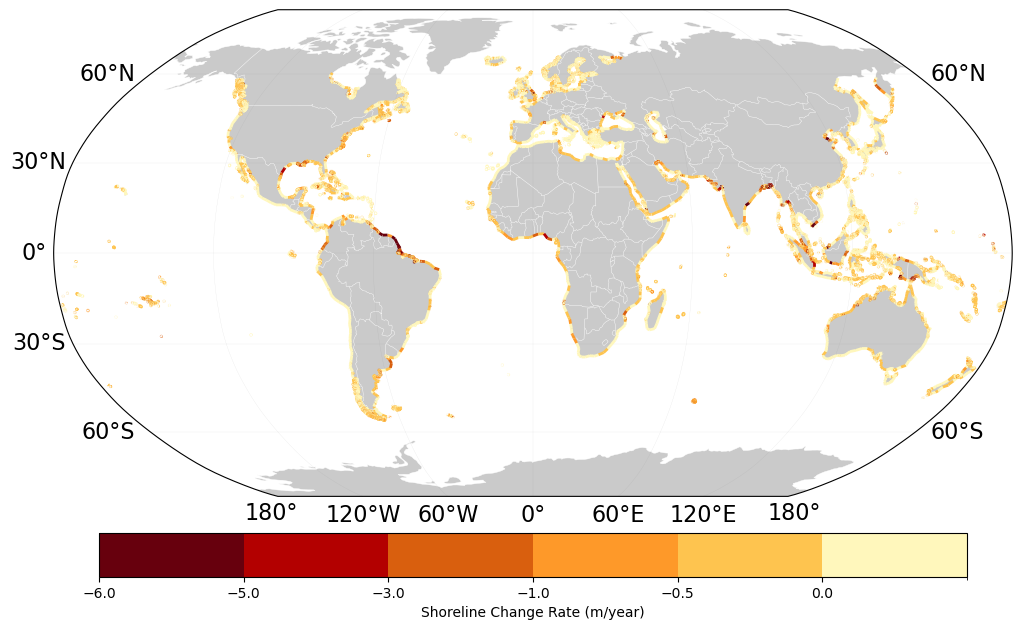

In [29]:
bins = [-6, -5, -3, -1, -0.5, 0, 1]


label = "Shoreline Change Rate (m/year)"
key = 'sds:change_rate'
df = aggregate_data(segments_gdf,joined, key)



cmap = mcolors.ListedColormap([
    "#fff7bc",  # stable / very low erosion
    "#fec44f",  # low erosion
    "#fe9929",  # moderate erosion
    "#d95f0e",  # high erosion
    "#b30000",  # very high erosion
    "#67000d",  # extreme erosion
]).reversed()


fig2 = visualize_hazard(df,key,bins = bins,label=label,cmap=cmap)




### Erosion and Accretion Distributions

The shoreline-change dataset is separated into erosional and accretional observations to examine their statistical distributions independently. Negative shoreline-change rates are converted to positive erosion magnitudes so that the magnitude of shoreline retreat can be directly compared with the magnitude of shoreline advance.

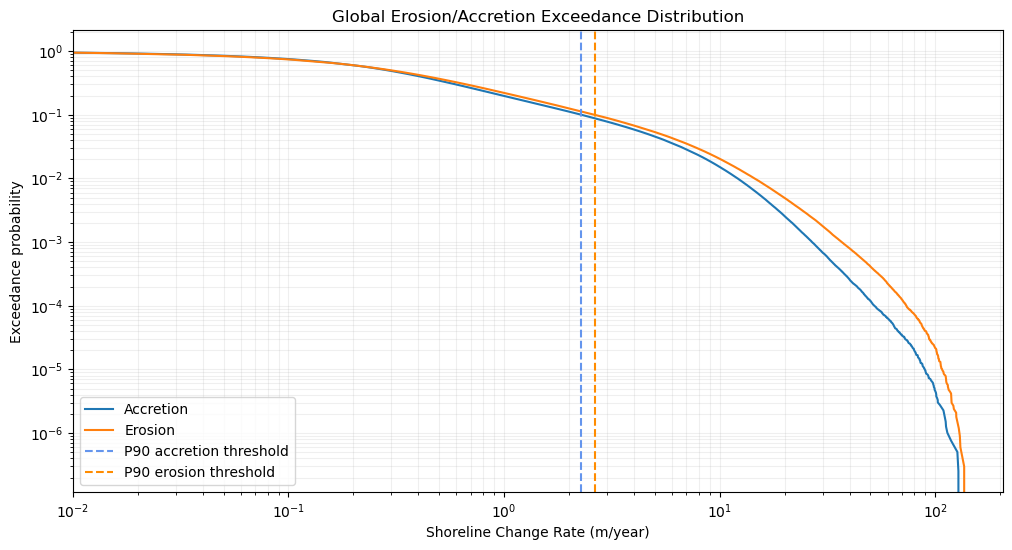

In [30]:
# split data
df_accretion = gdf_centroid.loc[gdf_centroid[key] >= 0].copy()

df_erosion = gdf_centroid.loc[gdf_centroid[key] < 0].copy()
df_erosion[key] = -df_erosion[key]   # convert to positive magnitude

# ECDF
x_acc, y_acc = ecdf(df_accretion, key)
x_er, y_er = ecdf(df_erosion, key)

# determine x-range
xmax = max(
    np.nanmax(x_acc),
    np.nanmax(x_er)
)

xmin = 0.01

# plot
fig, ax =plt.subplots(figsize=(12,6))

ax.plot(
    x_acc,
    1 - y_acc,
    # linewidth=2.5,
    label="Accretion"
)

ax.plot(
    x_er,
    1 - y_er,
    label="Erosion",
    # linestyle='--'
    # linewidth=2.5
)

    
for p in [90]:
    val = np.percentile(x_acc, p)
    plt.axvline(val, linestyle='--',color='cornflowerblue',label='P90 accretion threshold')
    val = np.percentile(x_er, p)
    plt.axvline(val, linestyle='--',color='darkorange',label='P90 erosion threshold')





plt.xscale("log")
plt.yscale("log")
plt.xlim(xmin, xmax)

plt.xlabel(label)
plt.ylabel("Exceedance probability")
plt.title("Global Erosion/Accretion Exceedance Distribution")

plt.grid(True, which="both", alpha=0.2)

plt.legend(loc='lower left')

plt.show()

## Global Distribution of Land Subsidence

The mapped land-subsidence data are visualized to identify coastal regions affected by different magnitudes of vertical land movement. Unlike the continuous flood-depth and shoreline-change datasets, the source subsidence dataset represents subsidence using discrete rate classes.

For global visualization, the transect-level subsidence information is aggregated to the generalized coastline segments. The resulting line segments are converted to representative points to improve the visibility of spatially concentrated high-subsidence observations at the global scale.

The classes are displayed using progressively stronger colors to distinguish low, moderate, and high subsidence conditions.

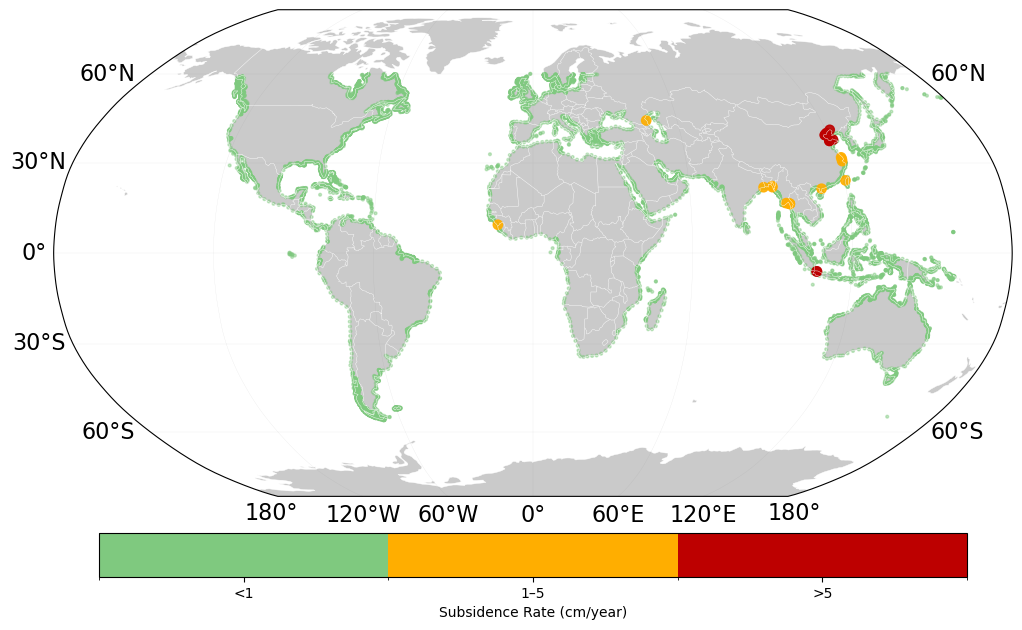

In [31]:

bins = [0, 3, 7.5, 12]

label = "Subsidence Rate (cm/year)"
key = 'subsidence'
df = aggregate_data(segments_gdf,joined, key)

df_centroid = df.copy().set_geometry(df.centroid)



cmap = mcolors.ListedColormap([
    "#7fc97f",  
    "#ffae00",  
    "#bd0000",  
])

# cmap = plt.cm.turbo
fig3 = visualize_subsidence(df_centroid,key,bins = bins,label=label,cmap=cmap)




### Distribution of Subsidence Classes

Global distribution is summarized using the relative frequency of each mapped subsidence class because the subsidence dataset is categorical rather than continuously distributed.

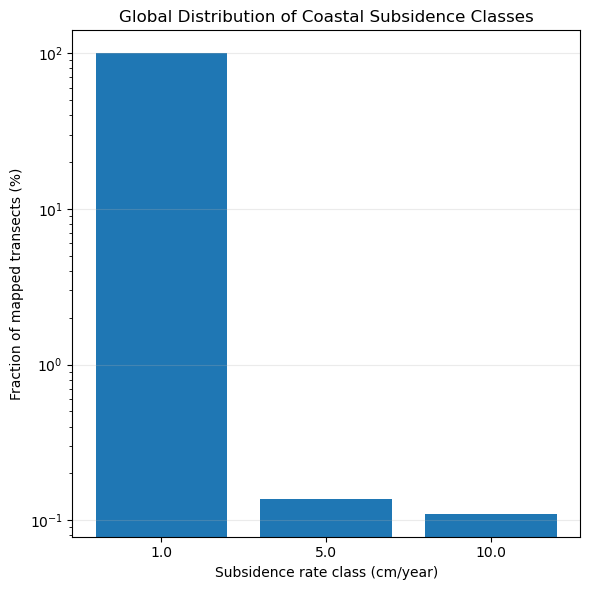

In [32]:
fig,ax = plt.subplots(figsize=(6,6))
counts = df["subsidence"].value_counts(normalize=True).sort_index() * 100

ax.bar(
    counts.index.astype(str),
    counts.values
)

ax.set_yscale("log")
ax.set_xlabel("Subsidence rate class (cm/year)")
ax.set_ylabel("Fraction of mapped transects (%)")
ax.set_title("Global Distribution of Coastal Subsidence Classes")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.show()